# DrugEx ROCS RNN Tutorial

## Overview
Comprehensive end-to-end workflow for ROCS-based molecular generation using DrugEx, mirroring the Sequence-RNN tutorial with ROCS scoring objectives.

## Workflow
1. **Transfer Learning**: Fine-tune pretrained RNN on CCR dataset
2. **Reinforcement Learning**: Train models across multiple conformer/scorer backends:
   - OpenEye (Omega conformers + ROCS CLI)
   - RDKit (aggregate + supermolecule)
   - CDPKit (aggregate + supermolecule)
3. **Sampling & Evaluation**: Generate molecules and cross-validate across backends

## Key Components
- **Conformer Generators**: Omega, RDKit, CDPKit
- **ROCS Scorers**: CLI-based, RDKit-based, CDPKit-based variants
- **Evaluation Metrics**: Shape/color similarity, scaffold analysis, novelty assessment
- **Cross-Backend Validation**: Native scoring comparison across all backends

## Prerequisites
- Python 3.10 with DrugEx
- RDKit
- OpenEye toolkits + ROCS CLI
- CDPKit
- CCR dataset and ROCS query files

## Output
Trained RL agents for each backend combination with comprehensive evaluation of generated molecule sets including scaffold diversity, novelty metrics, and cross-backend scoring consistency.

## Environment Setup

In [1]:
from __future__ import annotations

import os
import shutil
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path
from typing import Callable, Dict, Iterable, List, Optional

import numpy as np
import torch
import pandas as pd
from IPython.display import display, HTML
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import AllChem

from drugex.training.generators.sequence_rnn import SequenceRNN
from drugex.training.scorers.conformer_generators import (
    OmegaConformerGenerator,
    RDKitConformerGenerator,
    CDPKitConformerGenerator,
    OE_AVAILABLE as OMEGA_AVAILABLE,
    CDPL_AVAILABLE as CDPKIT_AVAILABLE,
)
from drugex.training.scorers.cli_rocs import CLIROCSScorer, OE_AVAILABLE as ROCS_AVAILABLE
from drugex.training.scorers.rdkit_rocs import (
    RDKitAggregateScorer,
    RDKitSupermoleculeScorer,
)
from drugex.training.scorers.cdpkit_rocs import (
    CDPKitROCSAggregateScorer,
    CDPKitROCSSupermoleculeScorer,
)
from drugex.training.scorers.modifiers import SmoothClippedScore
from drugex.training.scorers.properties import Property
from drugex.training.environment import DrugExEnvironment
from drugex.training.explorers.sequence_explorer import SequenceExplorer
from drugex.training.monitors import FileMonitor
from drugex.training.rewards import ParetoCrowdingDistance
from drugex.data.corpus.vocabulary import VocSmiles
from drugex.data.corpus.corpus import SequenceCorpus
from drugex.data.processing import CorpusEncoder, RandomTrainTestSplitter
from drugex.data.datasets import SmilesDataSet
from drugex.logs import logger

NOTEBOOK_NAME = "DrugEx_ROCS_RNN_Showcase.ipynb"


def locate_notebook_dir() -> Path:
    """Resolve the directory containing this notebook independent of CWD."""
    candidates: List[Path] = []
    try:
        nb_path = Path(__file__).resolve()
        candidates.append(nb_path.parent)
    except NameError:
        pass

    cwd = Path.cwd().resolve()
    candidates.append(cwd)

    env_dir = os.environ.get("DRUGEX_NOTEBOOK_DIR")
    if env_dir:
        candidates.append(Path(env_dir).expanduser())

    candidates.append(cwd / "tutorial" / "rocs")

    for candidate in candidates:
        try:
            candidate = candidate.resolve()
        except Exception:
            continue
        if (candidate / NOTEBOOK_NAME).exists():
            return candidate

    for parent in cwd.parents:
        candidate = (parent / "tutorial" / "rocs").resolve()
        if (candidate / NOTEBOOK_NAME).exists():
            return candidate

    return cwd


NOTEBOOK_DIR = locate_notebook_dir()


def locate_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists():
            return path
    return start


REPO_ROOT = locate_repo_root(NOTEBOOK_DIR)
DATA_ROOT = NOTEBOOK_DIR / "rocs_rl_ccr"
RESOURCES_DIR = DATA_ROOT / "rdkit_cdpkit"

CCR_DATA_PATH = RESOURCES_DIR / "CCR_HUMAN_AL.tsv"

RDKit_REF_SDF = RESOURCES_DIR / "CCR2_reference_ligands.sdf"
ROCS_QUERY = RDKit_REF_SDF
ROCS_SQ_QUERY = RESOURCES_DIR / "model3-4_v1.sq"

SUPER_SDF = RESOURCES_DIR / "supermol_123.sdf"

PRETRAINED_DIRS = [
    REPO_ROOT / "tutorial" / "data/models/pretrained/smiles-rnn/Papyrus05.5_smiles_rnn_PT",
    REPO_ROOT / "data/models/pretrained/smiles-rnn/Papyrus05.5_smiles_rnn_PT",
    NOTEBOOK_DIR / "../data/models/pretrained/smiles-rnn/Papyrus05.5_smiles_rnn_PT",
]
PRETRAINED_VOCAB = "Papyrus05.5_smiles_rnn_PT.vocab"
PRETRAINED_PKG = "Papyrus05.5_smiles_rnn_PT.pkg"

FINETUNE_DIR = DATA_ROOT / "finetune_runs"
FINETUNE_CHECKPOINT = DATA_ROOT / "finetune.pkg"
FINETUNE_VOCAB = DATA_ROOT / "finetune.vocab"

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Repository root: {REPO_ROOT}")
print(f"Data root: {DATA_ROOT}")

Notebook directory: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs
Repository root: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS
Data root: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr


## Resource Checklist

In [2]:
resources = [
    ("Omega toolkit", OMEGA_AVAILABLE, None),
    ("ROCS CLI", shutil.which("rocs") is not None, shutil.which("rocs")),
    ("CDPKit (CDPL)", CDPKIT_AVAILABLE, None),
    ("CCR dataset", CCR_DATA_PATH.exists(), CCR_DATA_PATH),
    ("ROCS query SDF", ROCS_QUERY.exists(), ROCS_QUERY),
    ("ROCS query SQ", ROCS_SQ_QUERY.exists(), ROCS_SQ_QUERY),
    ("RDKit reference SDF", RDKit_REF_SDF.exists(), RDKit_REF_SDF),
    ("Supermolecule SDF", SUPER_SDF.exists(), SUPER_SDF),
    ("Finetune checkpoint", FINETUNE_CHECKPOINT.exists(), FINETUNE_CHECKPOINT),
    ("Finetune vocab", FINETUNE_VOCAB.exists(), FINETUNE_VOCAB),
]

resource_df = pd.DataFrame(
    [
        {
            "resource": name,
            "available": bool(flag),
            "path": str(path) if path else "",
        }
        for name, flag, path in resources
    ]
)
resource_df



,resource,available,path
0,Omega toolkit,True,
1,ROCS CLI,True,/home/dodo/bin/rocs
2,CDPKit (CDPL),True,
3,CCR dataset,True,/home/dodo/Documents/projects/drugex-rocs/Drug...
4,ROCS query SDF,True,/home/dodo/Documents/projects/drugex-rocs/Drug...
5,ROCS query SQ,True,/home/dodo/Documents/projects/drugex-rocs/Drug...
6,RDKit reference SDF,True,/home/dodo/Documents/projects/drugex-rocs/Drug...
7,Supermolecule SDF,True,/home/dodo/Documents/projects/drugex-rocs/Drug...
8,Finetune checkpoint,True,/home/dodo/Documents/projects/drugex-rocs/Drug...
9,Finetune vocab,True,/home/dodo/Documents/projects/drugex-rocs/Drug...


## Data Preparation

In [3]:
if not CCR_DATA_PATH.exists():
    raise FileNotFoundError(f"CCR dataset missing: {CCR_DATA_PATH}")

ccr_df = pd.read_csv(CCR_DATA_PATH, sep="	").dropna(subset=["SMILES"])
SAMPLE_SIZE = 128
candidate_smiles = ccr_df["SMILES"].head(SAMPLE_SIZE).tolist()


def embed_reference(mol: Chem.Mol) -> Optional[Chem.Mol]:
    if mol is None:
        return None
    mol = Chem.AddHs(mol)
    status = AllChem.EmbedMolecule(mol, randomSeed=0xF00D)
    if status != 0:
        return None
    AllChem.UFFOptimizeMolecule(mol)
    return mol


@lru_cache(maxsize=1)
def load_rdkit_references() -> List[Chem.Mol]:
    refs: List[Chem.Mol] = []
    if not RDKit_REF_SDF.exists():
        return refs
    suppl = Chem.SDMolSupplier(str(RDKit_REF_SDF), removeHs=False)
    for mol in suppl:
        if mol is None:
            continue
        if mol.GetNumConformers() == 0:
            mol = embed_reference(mol)
        if mol is not None and mol.GetNumConformers() > 0:
            refs.append(mol)
    return refs


RDKit_REFERENCE_MOLS = load_rdkit_references()
print(f"Loaded {len(candidate_smiles)} candidate SMILES")
print(f"RDKit reference molecules available: {len(RDKit_REFERENCE_MOLS)}")

Loaded 128 candidate SMILES
RDKit reference molecules available: 5


## Transfer Learning Setup

Fine-tunes a pretrained RNN model on the CCR dataset to adapt it for domain-specific molecular generation.

In [4]:
RUN_TRANSFER = True
TRANSFER_CONFIG = {
    "epochs": 120,
    "train_split": 0.9,
    "chunk_size": 500,
    "batch_size": 256,
    "max_valid_size": 1000,
    "shuffle": True,
    "n_proc": 25,
}


def find_pretrained_dir() -> Path:
    for candidate in PRETRAINED_DIRS:
        vocab = candidate / PRETRAINED_VOCAB
        pkg = candidate / PRETRAINED_PKG
        if vocab.exists() and pkg.exists():
            return candidate
    raise FileNotFoundError("Papyrus pretrained checkpoint not found in configured locations")


@lru_cache(maxsize=1)
def load_vocabulary(update=False) -> VocSmiles:
    if FINETUNE_VOCAB.exists():
        return VocSmiles.fromFile(str(FINETUNE_VOCAB), encode_frags=False, max_len=100, min_len=10)
    pretrained_dir = find_pretrained_dir()
    return VocSmiles.fromFile(str(pretrained_dir / PRETRAINED_VOCAB), encode_frags=False, max_len=100, min_len=10)


def prepare_finetune_loaders(config: Dict) -> tuple:
    voc = load_vocabulary()
    smiles_all = ccr_df["SMILES"].dropna().tolist()
    splitter = RandomTrainTestSplitter(1.0 - config["train_split"], config["max_valid_size"], shuffle=config["shuffle"])
    smiles_train, smiles_valid = splitter(smiles_all)

    data_dir = DATA_ROOT / "encoded_rnn"
    data_dir.mkdir(parents=True, exist_ok=True)

    encoder = CorpusEncoder(
        SequenceCorpus,
        {
            "vocabulary": voc,
            "update_voc": False,
            "throw": True,
        },
        n_proc=config["n_proc"],
        chunk_size=config["chunk_size"],
    )

    train_collector = SmilesDataSet(data_dir / "ccr_train.tsv", rewrite=True)
    valid_collector = SmilesDataSet(data_dir / "ccr_valid.tsv", rewrite=True)

    encoder.apply(smiles_train, collector=train_collector)
    encoder.apply(smiles_valid, collector=valid_collector)

    train_loader = train_collector.asDataLoader(batch_size=config["batch_size"])
    valid_loader = valid_collector.asDataLoader(batch_size=config["batch_size"])
    return voc, train_loader, valid_loader


def run_transfer_learning(config: Dict, execute: bool = False) -> pd.DataFrame:
    records: List[Dict[str, str]] = []
    voc = load_vocabulary()
    pretrained_dir = find_pretrained_dir()
    pretrained_pkg = pretrained_dir / PRETRAINED_PKG

    if not execute:
        status = "skipped (set RUN_TRANSFER=True to execute)"
        if FINETUNE_CHECKPOINT.exists():
            status = "using cached finetune checkpoint"
        records.append(
            {
                "status": status,
                "checkpoint": str(FINETUNE_CHECKPOINT),
                "vocabulary": str(FINETUNE_VOCAB if FINETUNE_VOCAB.exists() else pretrained_dir / PRETRAINED_VOCAB),
                "epochs": config["epochs"],
            }
        )
        return pd.DataFrame(records)

    logger.setLevel("ERROR")
    voc, train_loader, valid_loader = prepare_finetune_loaders(config)

    model = SequenceRNN(voc=voc, is_lstm=True)
    model.loadStatesFromFile(str(pretrained_pkg))

    FINETUNE_DIR.mkdir(parents=True, exist_ok=True)
    monitor_prefix = FINETUNE_DIR / f"finetune_ep{config['epochs']}"
    monitor = FileMonitor(str(monitor_prefix), save_smiles=True, reset_directory=True)

    model.fit(train_loader, valid_loader, epochs=config["epochs"], monitor=monitor)

    torch_state_path = FINETUNE_CHECKPOINT
    model_state = model.state_dict()
    torch.save(model_state, torch_state_path)
    voc.toFile(str(FINETUNE_VOCAB))

    records.append(
        {
            "status": "finetune completed",
            "checkpoint": str(FINETUNE_CHECKPOINT),
            "vocabulary": str(FINETUNE_VOCAB),
            "epochs": config["epochs"],
        }
    )
    return pd.DataFrame(records)


In [5]:
transfer_summary = run_transfer_learning(TRANSFER_CONFIG, execute=RUN_TRANSFER)
transfer_summary

SequenceCorpus (batch processing):   0%|          | 0/1 [00:00<?, ?it/s]

SequenceCorpus (batch processing):   0%|          | 0/1 [00:00<?, ?it/s]

/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/drugex/training/interfaces.py:322: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.loadStates(torch.load(path, map_l

Fitting model:   0%|          | 0/120 [00:00<?, ?it/s]

,status,checkpoint,vocabulary,epochs
0,finetune completed,/home/dodo/Documents/projects/drugex-rocs/Drug...,/home/dodo/Documents/projects/drugex-rocs/Drug...,120


## Reinforcement Learning Backends

Each backend bundles a conformer generator, one or more scorers, threshold
settings, and an RL configuration. Set per-backend flags in `RL_EXECUTION` to
rerun training; otherwise existing checkpoints are used.

In [6]:
from re import T


@dataclass
class BackendSpec:
    label: str
    library: str
    builder: Callable[[], tuple]
    thresholds: List[float]
    rl_dir: Path
    agent_pkg: Path
    monitor_prefix: str
    run_key: str
    scalers: Optional[List[SmoothClippedScore]] = None
    notes: Optional[str] = None


RL_EXECUTION = {
    "openeye": True,
    "rdkit_aggregate": True,
    "rdkit_supermol": True,
    "cdpkit_aggregate": True,
    "cdpkit_supermol": True,
}

RL_DEFAULTS = {
    "epochs": 30,
    "batch_size": 256,
    "epsilon": 0.1,
    "n_samples": 130,
    "reload_interval": 25,
    "criteria": "desired_ratio",
}


def build_openeye_backend():
    if not OMEGA_AVAILABLE:
        return None, "OpenEye toolkits not available"
    if not ROCS_AVAILABLE:
        return None, "OpenEye ROCS Python bindings not available"
    if shutil.which("rocs") is None:
        return None, "ROCS CLI binary not found in PATH"
    
    # Check for available query files
    query_files = {}
    if ROCS_QUERY.exists():
        query_files["CCR2_SDF"] = str(ROCS_QUERY)
    if ROCS_SQ_QUERY.exists():
        query_files["Model3-4_SQ"] = str(ROCS_SQ_QUERY)
    
    if not query_files:
        return None, f"No ROCS query files found. Checked: {ROCS_QUERY}, {ROCS_SQ_QUERY}"

    generator = OmegaConformerGenerator(max_conformers=40, show_progress=False)
    scorer = CLIROCSScorer(
        conformer_generator=generator,
        # Use both SDF and .sq queries; CLIROCSScorer will return max score across all queries
        query_files=query_files,
        score_type="TanimotoCombo",
        show_progress=False,
    )
    return [scorer], "ready"


def build_rdkit_aggregate():
    if not RDKit_REFERENCE_MOLS:
        return None, "No RDKit reference molecules"
    generator = RDKitConformerGenerator(max_conformers=40, show_progress=False)
    scorer = RDKitAggregateScorer(
        conformer_generator=generator,
        reference_mols=RDKit_REFERENCE_MOLS,
        show_progress=False,
        n_jobs=-1,
    )
    return [scorer], "ready"


def build_rdkit_supermol():
    if not SUPER_SDF.exists():
        return None, f"Supermolecule SDF missing: {SUPER_SDF}"
    generator = RDKitConformerGenerator(max_conformers=40, show_progress=False)
    scorer = RDKitSupermoleculeScorer(
        conformer_generator=generator,
        supermol_file=str(SUPER_SDF),
        show_progress=False,
        n_jobs=-1,
    )
    return [scorer], "ready"


def build_cdpkit_aggregate():
    if not CDPKIT_AVAILABLE:
        return None, "CDPKit not available"
    if not RDKit_REF_SDF.exists():
        return None, f"Reference SDF missing: {RDKit_REF_SDF}"
    generator = CDPKitConformerGenerator(
        max_conformers=40,  
        max_centers=4,
        timeout=3600,      # seconds
        min_rmsd=0.5,       # Ångströms
        energy_window=20.0, # kcal/mol
        show_progress=False
    )
    scorer = CDPKitROCSAggregateScorer(
        conformer_generator=generator,
        reference_mols=[str(RDKit_REF_SDF)],
        show_progress=False,
        n_jobs=-1,
    )
    return [scorer], "ready"


def build_cdpkit_supermol():
    if not CDPKIT_AVAILABLE:
        return None, "CDPKit not available"
    if not SUPER_SDF.exists():
        return None, f"Supermolecule SDF missing: {SUPER_SDF}"
    generator = CDPKitConformerGenerator(
        max_conformers=40,  
        max_centers=4,
        timeout=3600,      # seconds
        min_rmsd=0.5,       # Ångströms
        energy_window=20.0, # kcal/mol
        show_progress=False
    )
    scorer = CDPKitROCSSupermoleculeScorer(
        conformer_generator=generator,
        supermol_file=str(SUPER_SDF),
        show_progress=False,
        n_jobs=-1,
    )
    return [scorer], "ready"



BACKENDS: Dict[str, BackendSpec] = {
    "openeye": BackendSpec(
        label="OpenEye (Omega + ROCS)",
        library="OpenEye",
        builder=build_openeye_backend,
        thresholds=[0.35],
        rl_dir=DATA_ROOT / "rl_runs" / "openeye_rocs",
        agent_pkg=DATA_ROOT / "rl_runs" / "openeye_rocs" / "openeye_rocs.pkg",
        monitor_prefix="openeye_rocs",
        run_key="openeye",
    ),
    "rdkit_aggregate": BackendSpec(
        label="RDKit Aggregate",
        library="RDKit",
        builder=build_rdkit_aggregate,
        thresholds=[0.35],
        rl_dir=DATA_ROOT / "rl_runs" / "rdkit_aggregate",
        agent_pkg=DATA_ROOT / "rl_runs" / "rdkit_aggregate" / "rdkit_aggregate.pkg",
        monitor_prefix="rdkit_aggregate",
        run_key="rdkit_aggregate",
    ),
    "rdkit_supermol": BackendSpec(
        label="RDKit Supermolecule",
        library="RDKit",
        builder=build_rdkit_supermol,
        thresholds=[0.25],
        rl_dir=DATA_ROOT / "rl_runs" / "rdkit_supermol",
        agent_pkg=DATA_ROOT / "rl_runs" / "rdkit_supermol" / "rdkit_supermol.pkg",
        monitor_prefix="rdkit_supermol",
        run_key="rdkit_supermol",
    ),
    "cdpkit_aggregate": BackendSpec(
        label="CDPKit Aggregate",
        library="CDPKit",
        builder=build_cdpkit_aggregate,
        thresholds=[0.35],
        rl_dir=DATA_ROOT / "rl_runs" / "cdpkit_aggregate",
        agent_pkg=DATA_ROOT / "rl_runs" / "cdpkit_aggregate" / "cdpkit_aggregate.pkg",
        monitor_prefix="cdpkit_aggregate",
        run_key="cdpkit_aggregate",
    ),
    "cdpkit_supermol": BackendSpec(
        label="CDPKit Supermolecule",
        library="CDPKit",
        builder=build_cdpkit_supermol,
        thresholds=[0.25],
        rl_dir=DATA_ROOT / "rl_runs" / "cdpkit_supermol",
        agent_pkg=DATA_ROOT / "rl_runs" / "cdpkit_supermol" / "cdpkit_supermol.pkg",
        monitor_prefix="cdpkit_supermol",
        run_key="cdpkit_supermol",
    ),
}

LABEL_TO_KEY = {spec.label: key for key, spec in BACKENDS.items()}



### RL Utilities

We follow the multi-objective pattern from `Sequence-RNN.ipynb` by pairing each shape scorer
with a synthetic accessibility (SA) observer. The environment automatically attaches a
`Property('SA')` scorer and clips it with `SmoothClippedScore(lower_x=5.0, upper_x=3.0)`,
ensuring reinforcement learning optimizes both TanimotoCombo and synthesizability.


In [7]:
def load_sequence_model(checkpoint: Path, voc: VocSmiles) -> SequenceRNN:
    if not checkpoint.exists():
        raise FileNotFoundError(f"Missing checkpoint: {checkpoint}")
    model = SequenceRNN(voc=voc, is_lstm=True)
    model.loadStatesFromFile(str(checkpoint))
    return model


def ensure_rl_dirs(spec: BackendSpec):
    spec.rl_dir.mkdir(parents=True, exist_ok=True)


SA_THRESHOLD = 0.1

def build_environment_and_modifier(scorers: List, thresholds: List[float]):
    """Attach default modifiers and a synthetic accessibility objective."""
    expanded_scorers = list(scorers)
    expanded_thresholds = list(thresholds)

    for scorer in expanded_scorers:
        if scorer.getModifier() is None:
            scorer.setModifier(SmoothClippedScore(upper_x=0.9, lower_x=0.4))

    def has_sa(scorer_list):
        for scorer in scorer_list:
            key = scorer.getKey()
            if isinstance(key, str) and key == "SA":
                return True
            if isinstance(key, list) and any(k == "SA" for k in key):
                return True
        return False

    if not has_sa(expanded_scorers):
        sa_scorer = Property("SA")
        sa_scorer.setModifier(SmoothClippedScore(lower_x=5.0, upper_x=3.0))
        expanded_scorers.append(sa_scorer)

    # Count scorer keys (not scorers) to match DrugExEnvironment logic
    scorer_keys = []
    for scorer in expanded_scorers:
        key = scorer.getKey()
        if isinstance(key, list):
            scorer_keys.extend(key)
        else:
            scorer_keys.append(key)
    
    # Ensure we have enough thresholds for all scorer keys
    while len(expanded_thresholds) < len(scorer_keys):
        expanded_thresholds.append(SA_THRESHOLD)

    env = DrugExEnvironment(
        scorers=expanded_scorers,
        thresholds=expanded_thresholds,
        reward_scheme=ParetoCrowdingDistance(),
    )
    return env


def run_rl_backend(spec: BackendSpec, execute: bool, rl_config: Dict, voc: VocSmiles) -> Dict:
    ensure_rl_dirs(spec)
    scorers, status = spec.builder()
    if scorers is None:
        return {
            "backend": spec.label,
            "status": status,
            "agent_path": str(spec.agent_pkg),
        }

    if not execute and spec.agent_pkg.exists():
        return {
            "backend": spec.label,
            "status": "using cached agent",
            "agent_path": str(spec.agent_pkg),
        }

    if not FINETUNE_CHECKPOINT.exists():
        return {
            "backend": spec.label,
            "status": "finetune checkpoint missing",
            "agent_path": str(spec.agent_pkg),
        }

    env = build_environment_and_modifier(scorers, spec.thresholds)
    agent = load_sequence_model(FINETUNE_CHECKPOINT, voc)
    mutate = load_sequence_model(FINETUNE_CHECKPOINT, voc)
    crover = load_sequence_model(FINETUNE_CHECKPOINT, voc)

    explorer = SequenceExplorer(
        agent=agent,
        env=env,
        mutate=mutate,
        crover=crover,
        batch_size=rl_config["batch_size"],
        epsilon=rl_config["epsilon"],
        n_samples=rl_config["n_samples"],
    )

    monitor = FileMonitor(
        str(spec.rl_dir / spec.monitor_prefix),
        save_smiles=True,
        reset_directory=True,
    )

    explorer.fit(
        epochs=rl_config["epochs"],
        monitor=monitor,
        reload_interval=rl_config.get("reload_interval", 25),
        criteria=rl_config.get("criteria", "desired_ratio"),
    )

    return {
        "backend": spec.label,
        "status": "rl completed",
        "agent_path": str(spec.agent_pkg),
    }


In [8]:
voc = load_vocabulary()
rl_records = []
for key, spec in BACKENDS.items():
    execute = RL_EXECUTION.get(spec.run_key, False)
    summary = run_rl_backend(spec, execute, RL_DEFAULTS, voc)
    rl_records.append(summary)
rl_df = pd.DataFrame(rl_records)
rl_df

/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/drugex/training/interfaces.py:322: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.loadStates(torch.load(path, map_l

Fitting SMILES RNN explorer:   0%|          | 0/30 [00:00<?, ?it/s]

Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf
Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/model3-4_v1.sq


Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf
Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/model3-4_v1.sq


...

Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

,backend,status,agent_path
0,OpenEye (Omega + ROCS),rl completed,/home/dodo/Documents/projects/drugex-rocs/Drug...
1,RDKit Aggregate,rl completed,/home/dodo/Documents/projects/drugex-rocs/Drug...
2,RDKit Supermolecule,rl completed,/home/dodo/Documents/projects/drugex-rocs/Drug...
3,CDPKit Aggregate,rl completed,/home/dodo/Documents/projects/drugex-rocs/Drug...
4,CDPKit Supermolecule,rl completed,/home/dodo/Documents/projects/drugex-rocs/Drug...


# DrugEx ROCS RL Backend Training Times

## Training Results (30 epochs each)

| Backend | Time | Per Epoch |
|---------|------|-----------|
| CDPKit Supermolecule | 2:54 | 5.41s |
| CDPKit Aggregate | 2:56 | 6.44s |
| RDKit Supermolecule | 12:05 | 24.28s |
| RDKit Aggregate | 12:44 | 46.41s |
| OpenEye ROCS | 15:40 | 26.79s |


- **Total training time**: 46 minutes


## Sampling & Cross-Backend Evaluation

Generates molecular samples from each trained RL agent to enable cross-backend validation. This systematic comparison across different conformer/scorer combinations (OpenEye, RDKit, CDPKit) quantifies backend consistency and identifies optimal molecular generation strategies for CCR ligands.

In [9]:
SAMPLE_CONFIG = {
    "per_backend": 1000,
    "batch_size": 256,
    "max_batches": 60,
}


def sample_unique_smiles(model: SequenceRNN, target_size: int, batch_size: int, max_batches: int) -> List[str]:
    if target_size <= 0:
        return []
    unique: List[str] = []
    seen: set[str] = set()
    for _ in range(max_batches):
        batch = model.sample(batch_size)
        for smi in batch:
            if smi not in seen:
                seen.add(smi)
                unique.append(smi)
                if len(unique) >= target_size:
                    return unique
    return unique


def load_agent_for_sampling(path: Path, voc: VocSmiles) -> Optional[SequenceRNN]:
    if not path.exists():
        return None
    model = SequenceRNN(voc=voc, is_lstm=True)
    model.loadStatesFromFile(str(path))
    return model


def collect_backend_samples(backends: Dict[str, BackendSpec], config: Dict, voc: VocSmiles) -> Dict[str, List[str]]:
    samples: Dict[str, List[str]] = {}
    for key, spec in backends.items():
        agent = load_agent_for_sampling(spec.agent_pkg, voc)
        if agent is None:
            continue
        
        # Sample unique SMILES using the agent
        smiles = sample_unique_smiles(
            agent, 
            config["per_backend"], 
            config["batch_size"], 
            config["max_batches"]
        )
        samples[spec.label] = smiles
    return samples

backend_samples = collect_backend_samples(BACKENDS, SAMPLE_CONFIG, voc)
{
    name: len(smiles) for name, smiles in backend_samples.items()
}

/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/drugex/training/interfaces.py:322: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.loadStates(torch.load(path, map_l

{'OpenEye (Omega + ROCS)': 1000,
 'RDKit Aggregate': 1000,
 'RDKit Supermolecule': 1000,
 'CDPKit Aggregate': 1000,
 'CDPKit Supermolecule': 1000}

## Cross-Backend Scoring Utilities

Provides functions to score molecular samples using any backend configuration, enabling systematic cross-validation of generated molecules across different conformer/scorer combinations.

In [10]:
def get_backend_spec_by_label(label: str):
    key = LABEL_TO_KEY.get(label)
    if key is None:
        return None, f"Unknown backend label: {label}"
    spec = BACKENDS[key]
    scorers, status = spec.builder()
    if scorers is None:
        return None, status
    return (spec, scorers), "ready"


def score_with_backend(label: str, smiles: List[str]) -> pd.Series:
    result, status = get_backend_spec_by_label(label)
    if result is None or not smiles:
        return pd.Series([np.nan] * len(smiles))
    spec, scorers = result
    env = build_environment_and_modifier(scorers, spec.thresholds)
    df_scores = env.getScores(smiles)
    keys = env.getScorerKeys()
    if len(keys) == 1:
        return pd.Series(df_scores[keys[0]])
    return df_scores[keys].mean(axis=1)


### Sample Sanitization and Desired Filtering

Canonicalizes generated SMILES, removes unsanitizable molecules, and filters for valid-desired compounds according to each backend's scoring criteria. This preprocessing ensures downstream analyses operate on chemically valid, high-scoring molecular sets.

In [11]:
from rdkit.Chem import SanitizeMol

def sanitize_smiles(smi: str) -> str | None:
    mol = Chem.MolFromSmiles(smi, sanitize=False)
    if mol is None:
        return None
    try:
        SanitizeMol(mol)
    except Exception:
        return None
    return Chem.MolToSmiles(mol, canonical=True)

filtered_backend_samples: dict[str, List[str]] = {}
backend_score_frames: dict[str, pd.DataFrame] = {}
for label, smiles_list in backend_samples.items():
    sanitized = [sanitize_smiles(s) for s in smiles_list]
    sanitized = [s for s in sanitized if s]
    result, status = get_backend_spec_by_label(label)
    if result is None or not sanitized:
        filtered_backend_samples[label] = []
        continue
    spec, scorers = result
    env = build_environment_and_modifier(scorers, spec.thresholds)
    score_df = env.getScores(sanitized)
    score_df["SMILES"] = sanitized
    mask = (score_df["Valid"] == 1) & (score_df["Desired"] == 1)
    filtered_backend_samples[label] = score_df.loc[mask, "SMILES"].tolist()
    backend_score_frames[label] = score_df

aggregate_samples = filtered_backend_samples
aggregate_scores = backend_score_frames
{label: len(smiles) for label, smiles in aggregate_samples.items()}


Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf
Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/model3-4_v1.sq


{'OpenEye (Omega + ROCS)': 148,
 'RDKit Aggregate': 782,
 'RDKit Supermolecule': 239,
 'CDPKit Aggregate': 794,
 'CDPKit Supermolecule': 50}

In [12]:
filtered_summary = pd.DataFrame.from_dict(
    {label: {"kept": len(smiles), "original": len(backend_samples.get(label, []))}
     for label, smiles in aggregate_samples.items()},
    orient="index"
)
filtered_summary["retention"] = filtered_summary["kept"] / filtered_summary["original"].replace({0: np.nan})
filtered_summary.sort_values("retention", ascending=False)


,kept,original,retention
CDPKit Aggregate,794,1000,0.794
RDKit Aggregate,782,1000,0.782
RDKit Supermolecule,239,1000,0.239
OpenEye (Omega + ROCS),148,1000,0.148
CDPKit Supermolecule,50,1000,0.050


The summary table reports how many sanitized, desired molecules remain per backend
compared with the original sampled totals. Expect higher retention once RL models
stabilize and produce more goal satisfying candidates.


The counts above reflect molecules that survived RDKit sanitization *and* met each backend's desirability thresholds.


### Native Score Summary

Diagonal entries in the cross-backend table reflect "native" scoring (each generator evaluated by its own backend). They serve as a quick reference for how consistently each policy attains its respective ROCS objective.

This section prepares filtered molecular samples for cross-backend evaluation by organizing sanitized, desired compounds from each backend into standardized collections. The native scores establish baseline performance metrics for each backend's trained policy, enabling systematic comparison of molecular generation quality across different conformer/scorer combinations.

## Cross-Backend Scoring (filtered sets)

Each filtered, desired collection is rescored against every backend. Scores reflect freshly generated conformers, so sample counts in the table correspond to the post-filtered molecules above.

Systematic cross-validation quantifies generation consistency across conformer/scorer combinations, identifying robust molecular generation strategies for CCR ligands.

In [13]:
ALL_BACKEND_LABELS = [
    "OpenEye (Omega + ROCS)",
    "RDKit Aggregate",
    "RDKit Supermolecule",
    "CDPKit Aggregate",
    "CDPKit Supermolecule",
]

# Filtered (sanitized + desired) samples used downstream
aggregate_samples = {
    label: filtered_backend_samples.get(label, [])
    for label in ALL_BACKEND_LABELS
}

# Raw sampling sizes retained for reference
RAW_SAMPLE_SIZES = {label: len(backend_samples.get(label, [])) for label in ALL_BACKEND_LABELS}
FILTERED_SAMPLE_SIZES = {label: len(smiles) for label, smiles in aggregate_samples.items()}

cross_records = []
for source_label, smiles_list in aggregate_samples.items():
    if not smiles_list:
        continue
    for scorer_label in ALL_BACKEND_LABELS:
        try:
            scores = score_with_backend(scorer_label, smiles_list)
            status = "ok"
        except Exception as exc:
            scores = pd.Series(dtype=float)
            status = f"error: {exc}"
        cross_records.append({
            "sampled_from": source_label,
            "scored_by": scorer_label,
            "mean_score": float(np.nanmean(scores)) if len(scores) else np.nan,
            "std_score": float(np.nanstd(scores)) if len(scores) else np.nan,
            "n": int(len(scores)),
            "status": status,
        })
cross_score_df = pd.DataFrame(cross_records)
cross_score_df

Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf
Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/model3-4_v1.sq


Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf
Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/model3-4_v1.sq
Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf
Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/model3-4_v1.sq


Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf
Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/model3-4_v1.sq
Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf
Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/model3-4_v1.sq


,sampled_from,scored_by,mean_score,std_score,n,status
0,OpenEye (Omega + ROCS),OpenEye (Omega + ROCS),0.672464,0.034439,148,ok
1,OpenEye (Omega + ROCS),RDKit Aggregate,0.919013,0.059877,148,ok
2,OpenEye (Omega + ROCS),RDKit Supermolecule,0.615515,0.077048,148,ok
3,OpenEye (Omega + ROCS),CDPKit Aggregate,0.857864,0.087487,148,ok
4,OpenEye (Omega + ROCS),CDPKit Supermolecule,0.559050,0.060020,148,ok
5,RDKit Aggregate,OpenEye (Omega + ROCS),0.626808,0.061703,782,ok
6,RDKit Aggregate,RDKit Aggregate,0.884256,0.071871,782,ok
7,RDKit Aggregate,RDKit Supermolecule,0.576337,0.058299,782,ok
8,RDKit Aggregate,CDPKit Aggregate,0.796343,0.097750,782,ok
9,RDKit Aggregate,CDPKit Supermolecule,0.540335,0.047135,782,ok


### Cross-Backend Analysis Results

Previous analysis will reveal which backend combinations produce the most consistent and high-scoring molecular sets, enabling identification of optimal generation strategies.

## Model Comparison

With the RL agents already trained for OpenEye ROCS, RDKit, and CDPKit, we can sample fresh molecules from each policy and study how their chemotypes diverge.

This section compares molecular generation across all five backend configurations (OpenEye, RDKit Aggregate, RDKit Supermolecule, CDPKit Aggregate, CDPKit Supermolecule) to analyze chemotype diversity and generation consistency.

In [14]:
ALL_BACKEND_LABELS = [
    "OpenEye (Omega + ROCS)",
    "RDKit Aggregate",
    "RDKit Supermolecule",
    "CDPKit Aggregate",
    "CDPKit Supermolecule",
]

aggregate_samples = {
    label: backend_samples.get(label, [])
    for label in ALL_BACKEND_LABELS
    if backend_samples.get(label)
}

if len(aggregate_samples) != len(ALL_BACKEND_LABELS):
    missing = sorted(set(ALL_BACKEND_LABELS) - set(aggregate_samples))
    print("Warning: missing samples for " + ", ".join(missing))
    
sample_summary = (
    pd.Series({label: len(smiles) for label, smiles in aggregate_samples.items()}, name="samples")
    .rename_axis("backend")
    .to_frame()
    .sort_values("samples", ascending=False)
)

sample_summary

,samples
backend,
OpenEye (Omega + ROCS),1000
RDKit Aggregate,1000
RDKit Supermolecule,1000
CDPKit Aggregate,1000
CDPKit Supermolecule,1000


### Murcko Scaffold Analysis


In [47]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
import pandas as pd
from collections import Counter

def bemis_murcko(smiles: str):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if not mol:
            return None
        scaf = MurckoScaffold.MakeScaffoldGeneric(MurckoScaffold.GetScaffoldForMol(mol))
        return Chem.MolToSmiles(scaf, canonical=True) if scaf.GetNumAtoms() else None
    except Exception:
        return None

def summarize_bemis(aggregate_samples: dict[str, list[str]]) -> pd.DataFrame:
    records = []
    for label, smiles_list in aggregate_samples.items():
        scafs = [s for s in map(bemis_murcko, smiles_list) if s]
        c = Counter(scafs)
        top = c.most_common(1)
        records.append({
            "backend": label,
            "unique_scaffolds": len(c),
            "top_scaffold": top[0][0] if top else None,
            "top_freq": top[0][1] if top else 0
        })
    return pd.DataFrame(records).sort_values("unique_scaffolds", ascending=False)

scaffold_summary = summarize_bemis(aggregate_samples)
scaffold_summary


,backend,unique_scaffolds,top_scaffold,top_freq
0,OpenEye (Omega + ROCS),332,CC(C1CCCCC1)C1CCCCC1CC(C)(C)C1CCCCC1,81
3,CDPKit Aggregate,311,CC(C1CCCCC1)C1CCCCC1CC(C)(C)C1CCCCC1,94
1,RDKit Aggregate,309,CC(C1CCCCC1)C1CCCCC1CC(C)(C)C1CCCCC1,104
2,RDKit Supermolecule,308,CC(C1CCCCC1)C1CCCCC1CC(C)(C)C1CCCCC1,86
4,CDPKit Supermolecule,278,CC(C1CCCCC1)C1CCCCC1CC(C)(C)C1CCCCC1,91


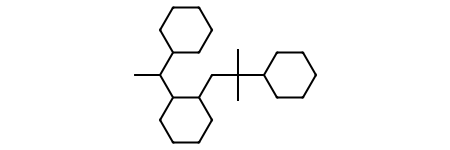

In [50]:
# visualize this smiles uisng rdkit in 2D O=C(c1ccncc1)c1ccccc1NS(=O)(=O)c1ccccc1	

# RDKit Molecule Visualization
from rdkit import Chem

# SMILES string for the molecule
smiles = "CC(C1CCCCC1)C1CCCCC1CC(C)(C)C1CCCCC1"

# Convert SMILES to RDKit molecule object
mol = Chem.MolFromSmiles(smiles)

mol

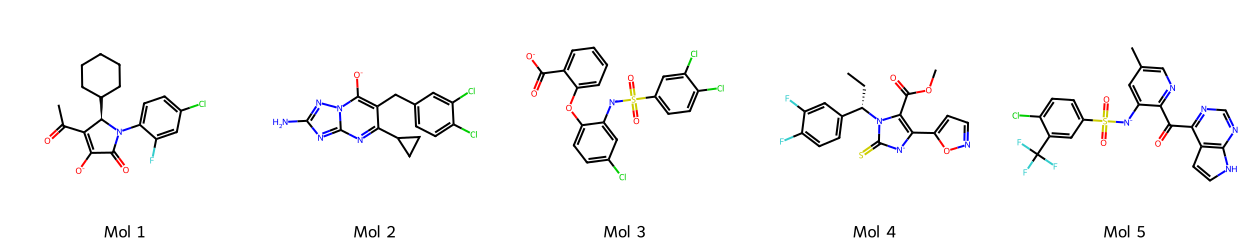

In [ ]:

from rdkit.Chem import AllChem, Draw

sdf_path = "rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf"  
mols = [m for m in Chem.SDMolSupplier(sdf_path) if m is not None]

mols = mols[:5]

for m in mols:
    AllChem.Compute2DCoords(m)

img = Draw.MolsToGridImage(
    mols, molsPerRow=5, subImgSize=(250, 250),
    legends=[f"Mol {i+1}" for i in range(len(mols))]
)
img


### Scaffold Gallery

Visual inspection of scaffold patterns reveals both generation bias (top scaffolds) and structural diversity (diverse scaffolds) across backend configurations.

**Analysis Components:**
- **Top scaffolds**: Shows generation bias and consistent structural preferences
- **Diverse scaffolds**: Displays scaffolds from different frequency bins to assess exploration
- **Overlap matrix**: Reveals structural diversity and convergence patterns between backends

In [48]:
from collections import Counter
import pandas as pd

TOP_K = 5
rows = []
for label, smiles_list in aggregate_samples.items():
    scafs = [s for s in map(bemis_murcko, smiles_list) if s]
    c = Counter(scafs)
    total = len(smiles_list) or 1
    for rank, (scaf, cnt) in enumerate(c.most_common(TOP_K), 1):
        rows.append({
            "backend": label,
            "rank": rank,
            "scaffold_smiles": scaf,
            "count": cnt,
            "fraction": cnt / total,
        })

top_scaffolds = pd.DataFrame(rows).sort_values(["backend", "rank"])
print("Top Scaffolds (Generation Bias):")
display(top_scaffolds)


Top Scaffolds (Generation Bias):


,backend,rank,scaffold_smiles,count,fraction
15,CDPKit Aggregate,1,CC(C1CCCCC1)C1CCCCC1CC(C)(C)C1CCCCC1,94,0.094
16,CDPKit Aggregate,2,CC(C)(CC1CCCCC1)C1CCCCC1,63,0.063
17,CDPKit Aggregate,3,CC(C)(CC1CCCCC1CC1CCCCC1)C1CCCCC1,50,0.050
18,CDPKit Aggregate,4,CC1CCC(C2CCCCC2)C1C1CCCCC1,33,0.033
19,CDPKit Aggregate,5,CC(CC1CCC(C(C)(C)CC2CCCCC2)C2CCCCC12)C1CCCCC1,29,0.029
20,CDPKit Supermolecule,1,CC(C1CCCCC1)C1CCCCC1CC(C)(C)C1CCCCC1,91,0.091
21,CDPKit Supermolecule,2,CC(C)(CC1CCCCC1)C1CCCCC1,70,0.070
22,CDPKit Supermolecule,3,CC(C)(CC1CCCCC1CC1CCCCC1)C1CCCCC1,41,0.041
23,CDPKit Supermolecule,4,CC(C1CCCCC1)C1CCCCC1CC(C)(C)C1CCC(C2CCCCC2)CC1,35,0.035
24,CDPKit Supermolecule,5,CC1CCC(C2CCCCC2)C1C1CCCCC1,32,0.032


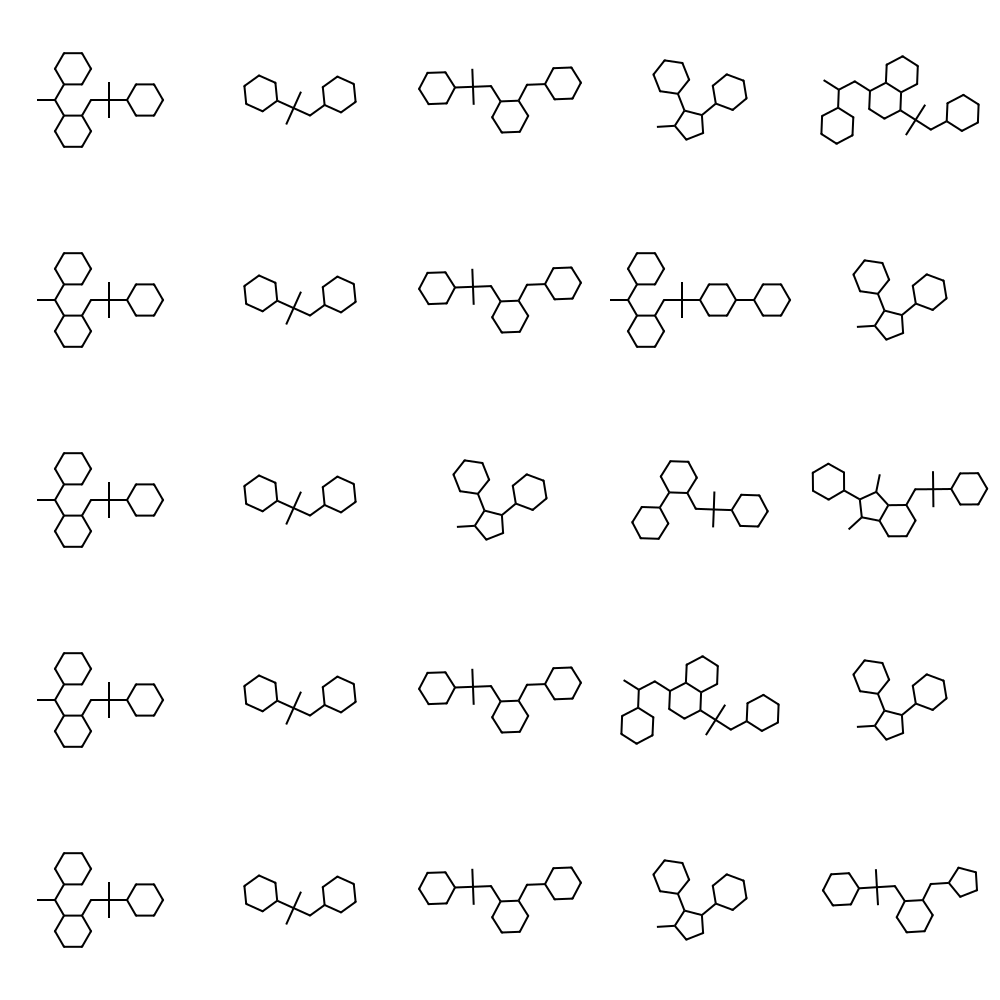

In [56]:
from rdkit import Chem
from rdkit.Chem.Draw import MolsMatrixToGridImage

# Suppose you want two rows, e.g. split your top K by backend or arbitrarily
rows = []
row_size = TOP_K  # or some splitting logic
smis = list(top_scaffolds["scaffold_smiles"])
for i in range(0, len(smis), row_size):
    sub = smis[i : i + row_size]
    row = [Chem.MolFromSmiles(s) for s in sub]
    rows.append(row)

# Compute 2D coords
for row in rows:
    for m in row:
        if m:
            Chem.rdDepictor.Compute2DCoords(m)

img = MolsMatrixToGridImage(
    molsMatrix=rows,
    subImgSize=(200, 200),
    useSVG=True
)
display(img)


In [57]:
from collections import Counter
import pandas as pd

def get_diverse_scaffolds(counter, n=5):
    if not counter: return []
    items = counter.most_common()
    step = max(len(items) // n, 1)
    return [items[i * step] for i in range(min(n, len(items)))]

rows = []
for label, smiles_list in aggregate_samples.items():
    c = Counter(s for s in map(bemis_murcko, smiles_list) if s)
    total = len(smiles_list) or 1
    for rank, (scaf, cnt) in enumerate(get_diverse_scaffolds(c, 5), 1):
        rows.append({
            "backend": label,
            "rank": rank,
            "scaffold_smiles": scaf,
            "count": cnt,
            "fraction": cnt / total
        })

diverse_scaffolds_df = pd.DataFrame(rows)
print("\nDiverse Scaffolds (Exploration Analysis):")
display(diverse_scaffolds_df)




Diverse Scaffolds (Exploration Analysis):


,backend,rank,scaffold_smiles,count,fraction
0,OpenEye (Omega + ROCS),1,CC(C1CCCCC1)C1CCCCC1CC(C)(C)C1CCCCC1,81,0.081
1,OpenEye (Omega + ROCS),2,CC(CCC1CCCCC1)C1CCCC2C(C3CCCCC3)CCC12,2,0.002
2,OpenEye (Omega + ROCS),3,CC(C)(CC1CCC2CCC2C1)C1CCCCC1,1,0.001
3,OpenEye (Omega + ROCS),4,CC1CCC2CCCCC12,1,0.001
4,OpenEye (Omega + ROCS),5,CC(C)(CC1CCCCCC1)C1CCC1C(C1CCCCC1)C1CCCCC1,1,0.001
5,RDKit Aggregate,1,CC(C1CCCCC1)C1CCCCC1CC(C)(C)C1CCCCC1,104,0.104
6,RDKit Aggregate,2,CC1CC(C(C)C2CCCCC2)C(C2CCCCC2)C1C1CCCCC1,2,0.002
7,RDKit Aggregate,3,CC(C1CCCC1)C(CCC1CCCC1)CC(C)(C)C1CCCC2CCCC21,1,0.001
8,RDKit Aggregate,4,CC1C2CCCCCC3CCCC(CC(C)(C)C4CCCCC4)C3C(C)C12,1,0.001
9,RDKit Aggregate,5,CC1CC(C)C2CC(C(C)(C)CC3CCCCC3)CCC12,1,0.001


In [ ]:
import pandas as pd

scaffold_sets = {
    lbl: {s for s in map(bemis_murcko, smis) if s}
    for lbl, smis in aggregate_samples.items()
}

labels = list(scaffold_sets.keys())
overlap = pd.DataFrame(index=labels, columns=labels, dtype=int)

for a in labels:
    for b in labels:
        overlap.loc[a, b] = len(scaffold_sets[a] & scaffold_sets[b])

print("\nScaffold Overlap Matrix:")
display(overlap)



Scaffold Overlap Matrix:


,OpenEye (Omega + ROCS),RDKit Aggregate,RDKit Supermolecule,CDPKit Aggregate,CDPKit Supermolecule
OpenEye (Omega + ROCS),332.0,88.0,87.0,92.0,80.0
RDKit Aggregate,88.0,309.0,84.0,97.0,82.0
RDKit Supermolecule,87.0,84.0,308.0,100.0,99.0
CDPKit Aggregate,92.0,97.0,100.0,311.0,103.0
CDPKit Supermolecule,80.0,82.0,99.0,103.0,278.0


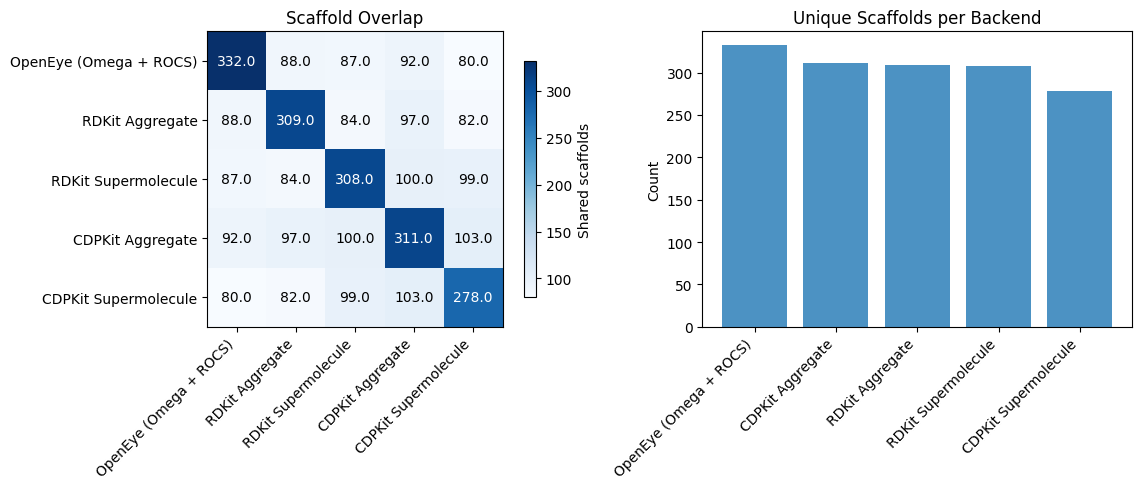

In [59]:
import matplotlib.pyplot as plt
import numpy as np

labels = overlap.index
vals = overlap.values
maxv = vals.max() or 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Heatmap ---
im = ax1.imshow(vals, cmap="Blues")
ax1.set_xticks(range(len(labels))); ax1.set_xticklabels(labels, rotation=45, ha="right")
ax1.set_yticks(range(len(labels))); ax1.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        v = vals[i, j]
        ax1.text(j, i, v, ha="center", va="center", color="white" if v > 0.6 * maxv else "black")
plt.colorbar(im, ax=ax1, shrink=0.8, label="Shared scaffolds")
ax1.set_title("Scaffold Overlap")

# --- Bar chart ---
ax2.bar(scaffold_summary.backend, scaffold_summary.unique_scaffolds, color="tab:blue", alpha=0.8)
ax2.set_title("Unique Scaffolds per Backend")
ax2.set_ylabel("Count")
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()


### Scaffold Concentration Metrics

Quantifies scaffold distribution inequality and generation concentration patterns across backends, providing context for novelty analysis against training data.

The table and bars highlight how much of each generator's output is concentrated in a handful of scaffold families versus long-tail exploration. High singleton ratios indicate the policy is still sampling many one-off chemotypes.

In [60]:
import numpy as np
import pandas as pd
from collections import Counter

def gini(x):
    x = np.sort(np.array(x, float))
    n = len(x)
    return 0 if n < 2 or x.sum() == 0 else (2*np.sum(np.arange(1, n+1)*x)/(n*x.sum()) - (n+1)/n)

rows = []
for label, smis in aggregate_samples.items():
    c = Counter(s for s in map(bemis_murcko, smis) if s)
    total = len(smis) or 1
    freqs = list(c.values())
    top5 = sum(sorted(freqs, reverse=True)[:5])
    rows.append({
        "backend": label,
        "unique_scaffolds": len(c),
        "unique_fraction": len(c)/total,
        "top5_fraction": top5/total,
        "gini_coefficient": gini(freqs)
    })

scaffold_metric_df = pd.DataFrame(rows).sort_values("gini_coefficient", ascending=False)
display(scaffold_metric_df)


,backend,unique_scaffolds,unique_fraction,top5_fraction,gini_coefficient
4,CDPKit Supermolecule,278,0.278,0.269,0.621856
3,CDPKit Aggregate,311,0.311,0.269,0.596147
2,RDKit Supermolecule,308,0.308,0.258,0.594828
1,RDKit Aggregate,309,0.309,0.262,0.588102
0,OpenEye (Omega + ROCS),332,0.332,0.260,0.571863


## Novelty Against Transfer Set

Assesses molecular novelty by computing Morgan fingerprint similarities between generated molecules and the CCR training set. Lower maximum similarities indicate exploration beyond the transfer learning corpus.

This analysis quantifies the exploration-exploitation trade-off: high similarity suggests the model exploits learned patterns, while low similarity indicates exploration of novel chemical space.

In [62]:
### Molecular Similarity Analysis

from rdkit.Chem import AllChem

def morgan_fp(smiles: str, radius: int = 2, n_bits: int = 2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)

transfer_smiles = [s for s in ccr_df["SMILES"].dropna().tolist()]
transfer_fps = [fp for smi in transfer_smiles if (fp := morgan_fp(smi)) is not None]

novelty_distributions: dict[str, pd.Series] = {}
novelty_rows = []
for label, smiles_list in aggregate_samples.items():
    similarities = []
    for smi in smiles_list:
        fp = morgan_fp(smi)
        if fp is None:
            continue
        sims = DataStructs.BulkTanimotoSimilarity(fp, transfer_fps)
        similarities.append(max(sims) if sims else float("nan"))
    series = pd.Series(similarities, name=label).dropna()
    novelty_distributions[label] = series
    if series.empty:
        novelty_rows.append({
            "backend": label,
            "mean_max_similarity": np.nan,
            "median_max_similarity": np.nan,
            "fraction_below_0_4": np.nan,
            "fraction_below_0_6": np.nan,
        })
    else:
        novelty_rows.append({
            "backend": label,
            "mean_max_similarity": series.mean(),
            "median_max_similarity": series.median(),
            "fraction_below_0_4": (series < 0.4).mean(),
            "fraction_below_0_6": (series < 0.6).mean(),
        })

novelty_summary = pd.DataFrame(novelty_rows).sort_values("mean_max_similarity")
novelty_summary

,backend,mean_max_similarity,median_max_similarity,fraction_below_0_4,fraction_below_0_6
0,OpenEye (Omega + ROCS),0.649948,0.677693,0.251748,0.442890
2,RDKit Supermolecule,0.666744,0.698413,0.224972,0.426322
3,CDPKit Aggregate,0.696907,0.754386,0.239501,0.360953
1,RDKit Aggregate,0.702101,0.763636,0.232019,0.350348
4,CDPKit Supermolecule,0.722476,0.783461,0.204128,0.337156


### Similarity Distribution Analysis

The distributions reveal the balance between exploitation (high similarity to training data) and exploration (low similarity, novel chemistry). Backends with broader distributions demonstrate more diverse generation strategies.

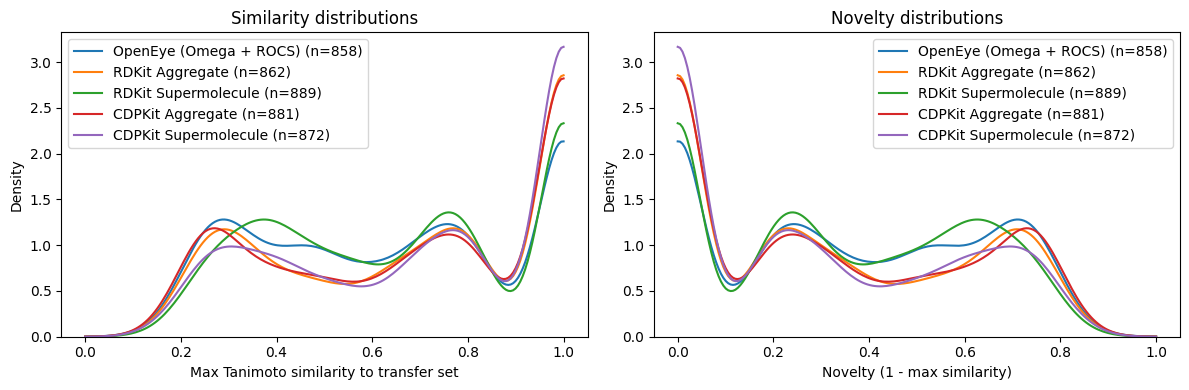

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, series in novelty_distributions.items():
    clean = series.dropna()
    if len(clean) < 2:
        continue
    sns.kdeplot(clean, ax=axes[0], label=f"{label} (n={len(clean)})", bw_adjust=0.7, clip=(0, 1))
axes[0].set_xlabel("Max Tanimoto similarity to transfer set")
axes[0].set_ylabel("Density")
axes[0].set_title("Similarity distributions")
axes[0].legend()

for label, series in novelty_distributions.items():
    clean = series.dropna()
    if len(clean) < 2:
        continue
    novelty = 1 - clean
    sns.kdeplot(novelty, ax=axes[1], label=f"{label} (n={len(clean)})", bw_adjust=0.7, clip=(0, 1))
axes[1].set_xlabel("Novelty (1 - max similarity)")
axes[1].set_ylabel("Density")
axes[1].set_title("Novelty distributions")
axes[1].legend()

plt.tight_layout()
plt.show()

### Novelty Quantiles

Quantile analysis reveals the distribution of novelty across generated molecules, identifying which backends produce more consistently novel or more consistently similar molecules to the training set.

The novelty plots diagnose whether any backend collapses back onto training chemistry (curves skewed toward similarity 1.0) or continues to explore unseen regions (mass near novelty 1.0).

In [64]:
novelty_stats = []
for label, series in novelty_distributions.items():
    clean = series.dropna()
    if clean.empty:
        continue
    novelty = 1 - clean
    novelty_stats.append({
        "backend": label,
        "similarity_p25": clean.quantile(0.25),
        "similarity_p50": clean.quantile(0.50),
        "similarity_p75": clean.quantile(0.75),
        "novelty_p25": novelty.quantile(0.25),
        "novelty_p50": novelty.quantile(0.50),
        "novelty_p75": novelty.quantile(0.75),
    })
novelty_percentiles = pd.DataFrame(novelty_stats)
novelty_percentiles

,backend,similarity_p25,similarity_p50,similarity_p75,novelty_p25,novelty_p50,novelty_p75
0,OpenEye (Omega + ROCS),0.396884,0.677693,1.0,0.0,0.322307,0.603116
1,RDKit Aggregate,0.422571,0.763636,1.0,0.0,0.236364,0.577429
2,RDKit Supermolecule,0.413793,0.698413,1.0,0.0,0.301587,0.586207
3,CDPKit Aggregate,0.416667,0.754386,1.0,0.0,0.245614,0.583333
4,CDPKit Supermolecule,0.450911,0.783461,1.0,0.0,0.216539,0.549089


### Scaffold-Level Novelty

Complement molecular similarity with scaffold-level novelty by comparing Bemis-Murcko scaffolds between generated and training sets.

In [65]:
import pandas as pd

# --- Reference (training / transfer) scaffolds ---
transfer_scaffolds = {s for s in map(bemis_murcko, transfer_smiles) if s}

# --- Novelty analysis ---
rows = []
for label, smiles_list in aggregate_samples.items():
    scaffolds = {s for s in map(bemis_murcko, smiles_list) if s}
    if not scaffolds: 
        continue
    novel = scaffolds - transfer_scaffolds
    shared = scaffolds & transfer_scaffolds
    rows.append({
        "backend": label,
        "total_scaffolds": len(scaffolds),
        "novel_scaffolds": len(novel),
        "shared_scaffolds": len(shared),
        "novelty_fraction": len(novel) / len(scaffolds)
    })

scaffold_novelty_df = pd.DataFrame(rows).sort_values("novelty_fraction", ascending=False)
display(scaffold_novelty_df)


,backend,total_scaffolds,novel_scaffolds,shared_scaffolds,novelty_fraction
0,OpenEye (Omega + ROCS),332,270,62,0.813253
2,RDKit Supermolecule,308,237,71,0.769481
1,RDKit Aggregate,309,230,79,0.744337
3,CDPKit Aggregate,311,227,84,0.729904
4,CDPKit Supermolecule,278,201,77,0.723022


This table shows how many unique Bemis–Murcko scaffolds each backend generated, how many of them were new compared to the transfer set, and what fraction were novel. Higher novelty fractions indicate more scaffold innovation, with OpenEye (Omega + ROCS) showing the highest novelty.


## Native Score Distributions

Analyzes score distribution shapes for each backend using native scoring pipelines. Distribution analysis reveals generation consistency: narrow distributions indicate consistent high-quality generation, while broad or multimodal distributions suggest diverse but potentially inconsistent output.

In [26]:
# Native scoring with each backend's own toolkit
native_scores: dict[str, pd.DataFrame] = {}
for label in ALL_BACKEND_LABELS:
    smiles_list = aggregate_samples.get(label, [])
    if not smiles_list:
        continue
    result, status = get_backend_spec_by_label(label)
    if result is None:
        continue
    spec, scorers = result
    env = build_environment_and_modifier(scorers, spec.thresholds)
    df_scores = env.getScores(smiles_list)
    df_scores["SMILES"] = smiles_list
    native_scores[label] = df_scores

print(f"Native scoring completed for: {list(native_scores.keys())}")

Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf
Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/model3-4_v1.sq
Native scoring completed for: ['OpenEye (Omega + ROCS)', 'RDKit Aggregate', 'RDKit Supermolecule', 'CDPKit Aggregate', 'CDPKit Supermolecule']


### Distribution Visualization

Histograms reveal score distribution shapes, diagnosing whether backends produce consistently high scores (narrow, high-centered distributions) or explore diverse chemical space with variable scoring (broad distributions).

/tmp/ipykernel_2870840/394385828.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].set_ylabel("Density"); axes[-1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")


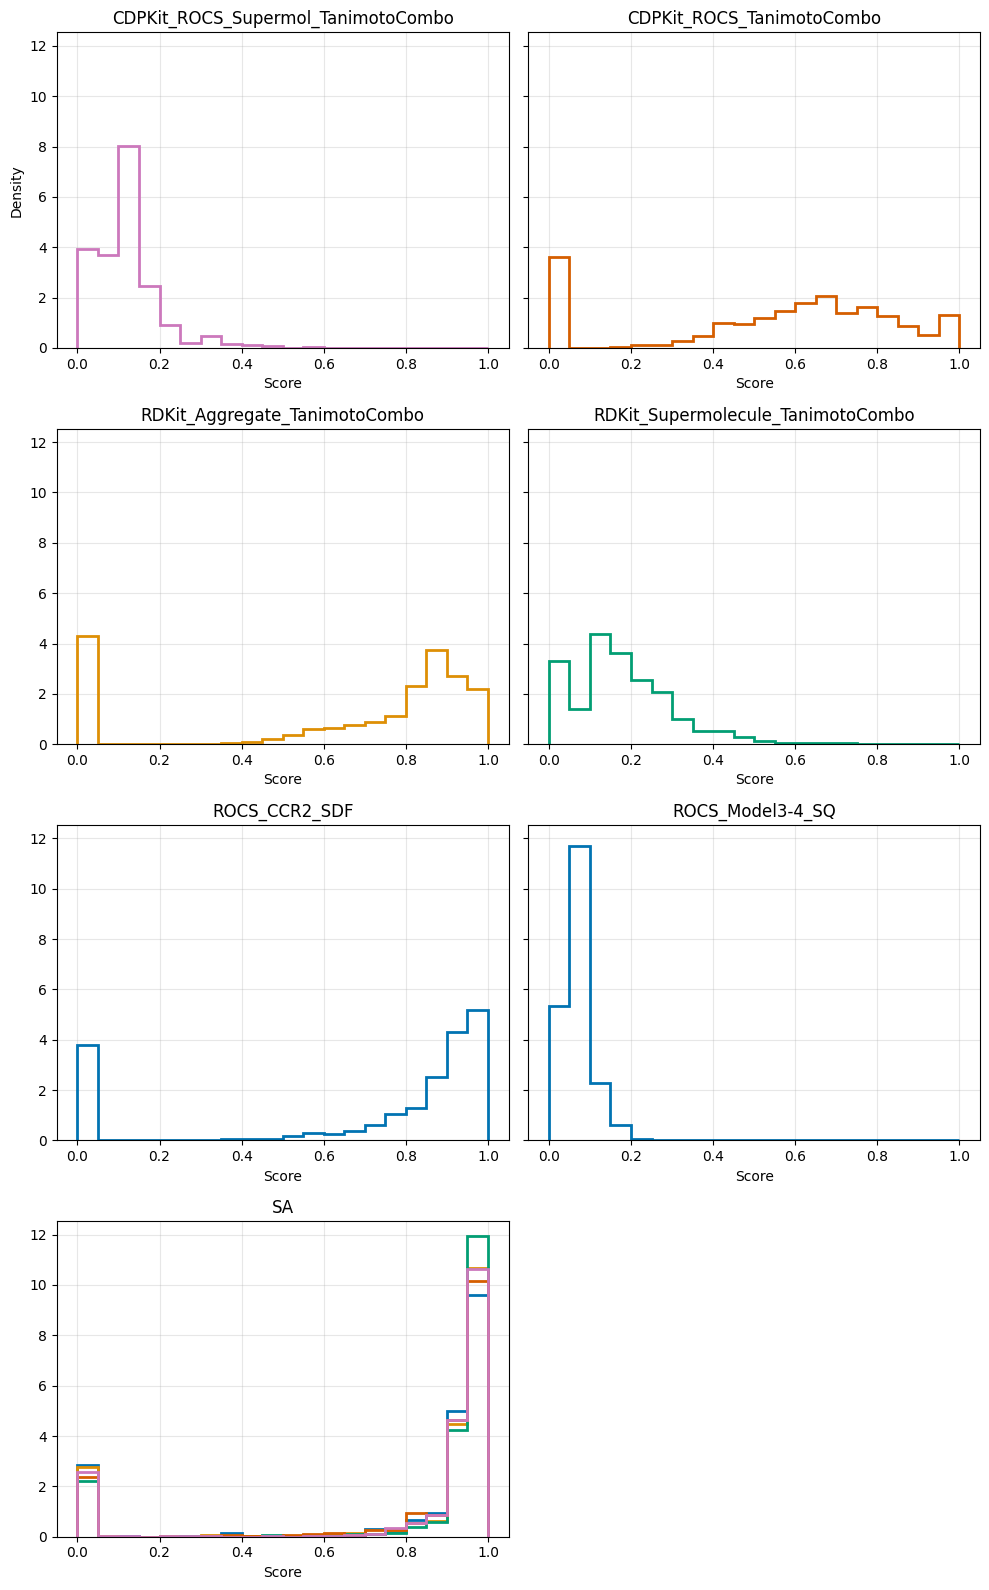

In [66]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

metrics = sorted({
    c for df in native_scores.values()
    for c in df.select_dtypes(include=[float, int]).columns
} - {"Valid", "Desired", "SMILES"})

if metrics:
    palette = dict(zip(ALL_BACKEND_LABELS, sns.color_palette("colorblind", len(ALL_BACKEND_LABELS))))
    bins = np.linspace(0, 1, 21)
    n = len(metrics)
    fig, axes = plt.subplots((n + 1)//2, 2, figsize=(10, 4*((n + 1)//2)), sharey=True)
    axes = np.ravel(axes)

    for ax, m in zip(axes, metrics):
        for label, df in native_scores.items():
            if m in df:
                vals = df[m].replace([np.inf, -np.inf], np.nan).dropna()
                if len(vals) > 1:
                    ax.hist(vals, bins=bins, density=True, histtype="step",
                            lw=2, color=palette[label], label=f"{label} (n={len(vals)})")
        ax.set_title(m); ax.set_xlabel("Score"); ax.grid(alpha=0.3)
    for ax in axes[len(metrics):]: ax.set_visible(False)
    axes[0].set_ylabel("Density"); axes[-1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout(); plt.show()
else:
    print("No numeric metrics available.")


## Reinforcement Learning Progress

Analyzes RL training dynamics to validate convergence and contextualize molecular generation quality. Training metrics reveal whether backends successfully optimize for ROCS objectives.

In [28]:
# Load RL training monitor logs
rl_metric_frames = []
for label, spec in BACKENDS.items():
    fit_path = spec.rl_dir / f"{spec.monitor_prefix}_fit.tsv"
    if fit_path.exists():
        df = pd.read_csv(fit_path, sep="\t")
        df["backend"] = label
        rl_metric_frames.append(df)


### Training Dynamics

Plots reveal convergence patterns and training stability across backends. Plateau behavior indicates optimization trade-offs between objectives.

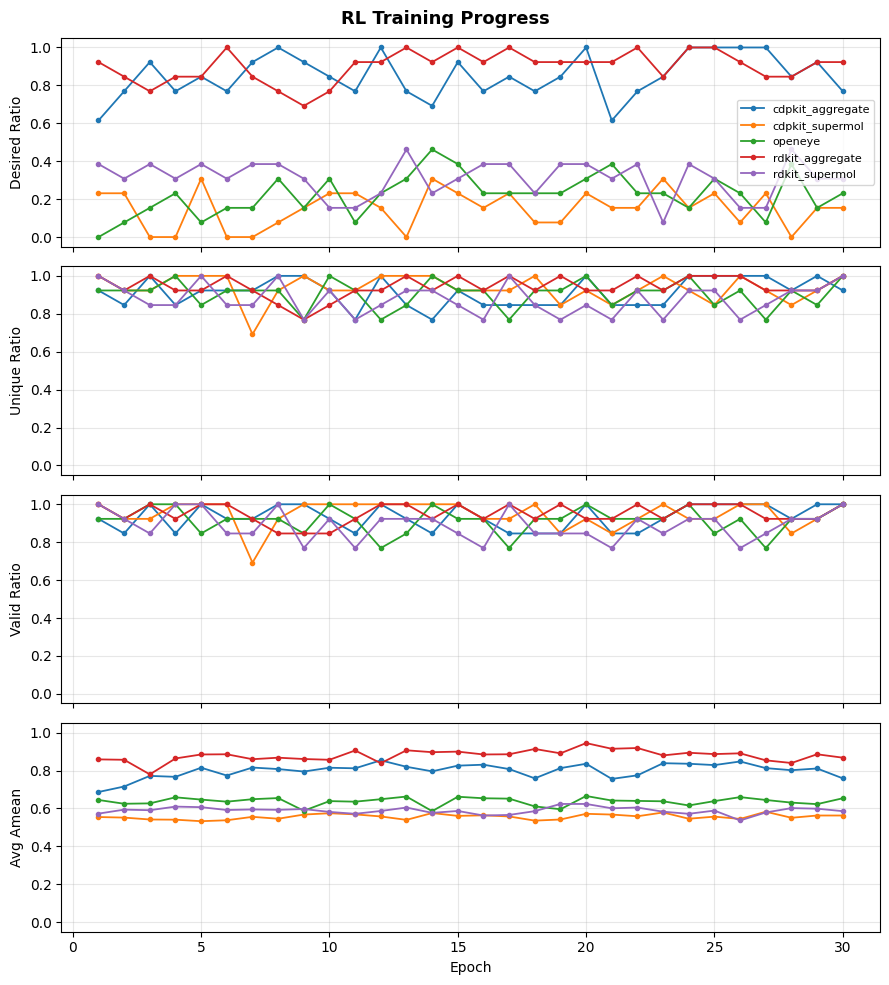

,desired_ratio,unique_ratio,valid_ratio,avg_amean
backend,,,,
cdpkit_aggregate,0.769,0.923,1.0,0.759
cdpkit_supermol,0.154,1.000,1.0,0.563
openeye,0.231,1.000,1.0,0.654
rdkit_aggregate,0.923,1.000,1.0,0.868
rdkit_supermol,0.308,1.000,1.0,0.586


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

frames = []
for label, spec in BACKENDS.items():
    p = spec.rl_dir / f"{spec.monitor_prefix}_fit.tsv"
    if p.exists():
        df = pd.read_csv(p, sep="\t"); df["backend"] = label; frames.append(df)
rl = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

if not rl.empty:
    metrics = ["desired_ratio", "unique_ratio", "valid_ratio", "avg_amean"]
    fig, axes = plt.subplots(len(metrics), 1, figsize=(9, 10), sharex=True, sharey=True)

    for ax, m in zip(axes, metrics):
        for label, grp in rl.groupby("backend"):
            ax.plot(grp["Epoch"], grp[m], marker="o", ms=3, lw=1.3, label=label)
        ax.set_ylabel(m.replace("_", " ").title())
        ax.grid(alpha=0.3)

    axes[-1].set_xlabel("Epoch")
    axes[0].legend(fontsize=8)
    fig.suptitle("RL Training Progress", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    last = rl.sort_values(["backend", "Epoch"]).groupby("backend").tail(1)
    display(last.set_index("backend")[metrics].round(3))
else:
    print("No RL metrics available.")
